# NovaCart E-commerce Analytics
## Notebook 03 — Exploratory Data Analysis

This notebook uses the cleaned datasets created in `02_data_cleaning.ipynb`.

### Main business questions

We will answer:

- How much revenue and profit did the business generate?
- How are revenue and profit trending over time?
- Which categories and products perform best?
- Which products generate strong sales but weak profit?
- Which customer segments create the most value?
- How many customers are repeat customers?
- Which acquisition channels perform best?
- How do discounts affect profitability?
- Which products/categories have high return rates?
- Which cities generate the most sales?
- How efficient are the marketing channels?
- What insights should management act on?

The goal is to produce insights that can later be recreated in Power BI.

## 1. Import libraries

In [41]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Load cleaned datasets

In [42]:
PROJECT_ROOT = Path("..")
CLEAN_DIR = PROJECT_ROOT / "data" / "cleaned"

customers = pd.read_csv(
    CLEAN_DIR / "customers_clean.csv",
    parse_dates=["Signup_Date"]
)

products = pd.read_csv(
    CLEAN_DIR / "products_clean.csv"
)

orders = pd.read_csv(
    CLEAN_DIR / "orders_clean.csv",
    parse_dates=["Order_Date", "Ship_Date"]
)

order_items = pd.read_csv(
    CLEAN_DIR / "order_items_clean.csv"
)

returns = pd.read_csv(
    CLEAN_DIR / "returns_clean.csv",
    parse_dates=["Return_Date"]
)

marketing = pd.read_csv(
    CLEAN_DIR / "marketing_clean.csv",
    parse_dates=["Month"]
)

print("Clean datasets loaded successfully.")

Clean datasets loaded successfully.


## 3. Dataset overview

In [43]:
overview = pd.DataFrame({
    "Dataset": ["customers", "products", "orders", "order_items", "returns", "marketing"],
    "Rows": [
        len(customers),
        len(products),
        len(orders),
        len(order_items),
        len(returns),
        len(marketing)
    ],
    "Columns": [
        customers.shape[1],
        products.shape[1],
        orders.shape[1],
        order_items.shape[1],
        returns.shape[1],
        marketing.shape[1]
    ]
})

overview

,Dataset,Rows,Columns
0,customers,25000,7
1,products,1200,9
2,orders,111900,8
3,order_items,227167,11
4,returns,16054,8
5,marketing,360,10


# Part A — Build Analysis Tables

## 4. Create transaction-level analysis table

We combine order items with orders, customers, and products.

This will be the primary dataframe for most EDA.

In [44]:
sales = (
    order_items
    .merge(
        orders,
        on="Order_ID",
        how="left"
    )
    .merge(
        customers,
        on="Customer_ID",
        how="left"
    )
    .merge(
        products,
        on="Product_ID",
        how="left",
        suffixes=("", "_Product")
    )
)

print("Sales analysis rows:", len(sales))
display(sales.head())

Sales analysis rows: 227167


,Order_Item_ID,Order_ID,Product_ID,Quantity,Unit_Price,Discount_Pct,Gross_Sales,Discount_Amount,Net_Sales,Cost_Amount,Profit,Customer_ID,Order_Date,Channel,Payment_Method,Shipping_Method,Order_Status,Ship_Date,Customer_Name,City,State,Customer_Segment,Signup_Date,Email_Opt_In,Product_Name,Category,Subcategory,Brand,List_Price,Unit_Cost,Base_Margin,Base_Return_Rate
0,OI00000001,O0000001,P01120,1,22.55,0.10,22.55,2.26,20.30,13.95,6.35,C013283,2024-01-01,Marketplace,Credit Card,Standard,Completed,2024-01-04,Nancy Jackson,Boston,MA,Consumer,2024-10-16,Yes,Novexa Lite Stationery,Office,Stationery,Novexa,22.55,13.95,0.38,0.04
1,OI00000002,O0000001,P00781,1,26.91,0.00,26.91,0.00,26.91,15.87,11.04,C013283,2024-01-01,Marketplace,Credit Card,Standard,Completed,2024-01-04,Nancy Jackson,Boston,MA,Consumer,2024-10-16,Yes,Mavix Prime Cookware,Home & Kitchen,Cookware,Mavix,26.91,15.87,0.41,0.06
2,OI00000003,O0000002,P00324,1,55.49,0.10,55.49,5.55,49.94,30.60,19.34,C023509,2024-01-01,Email,Credit Card,Standard,Completed,2024-01-05,William Gonzalez,Nashville,TN,Consumer,2024-11-21,Yes,Lumex Comfort Bags,Fashion,Bags,Lumex,55.49,30.60,0.45,0.13
3,OI00000004,O0000002,P00283,4,156.92,0.10,627.68,62.77,564.91,413.32,151.59,C023509,2024-01-01,Email,Credit Card,Standard,Completed,2024-01-05,William Gonzalez,Nashville,TN,Consumer,2024-11-21,Yes,Mirello Classic Cookware,Home & Kitchen,Cookware,Mirello,156.92,103.33,0.34,0.06
4,OI00000005,O0000002,P00318,1,54.68,0.05,54.68,2.73,51.95,38.04,13.91,C023509,2024-01-01,Email,Credit Card,Standard,Completed,2024-01-05,William Gonzalez,Nashville,TN,Consumer,2024-11-21,Yes,Novexa Classic Fitness,Sports & Outdoors,Fitness,Novexa,54.68,38.04,0.30,0.07


## 5. Add useful time columns

In [45]:
sales["Year"] = sales["Order_Date"].dt.year
sales["Month"] = sales["Order_Date"].dt.month
sales["Month_Name"] = sales["Order_Date"].dt.month_name()
sales["Year_Month"] = sales["Order_Date"].dt.to_period("M").astype(str)
sales["Quarter"] = "Q" + sales["Order_Date"].dt.quarter.astype(str)
sales["Day_Name"] = sales["Order_Date"].dt.day_name()

display(
    sales[
        ["Order_Date", "Year", "Month", "Month_Name", "Year_Month", "Quarter", "Day_Name"]
    ].head()
)

,Order_Date,Year,Month,Month_Name,Year_Month,Quarter,Day_Name
0,2024-01-01,2024,1,January,2024-01,Q1,Monday
1,2024-01-01,2024,1,January,2024-01,Q1,Monday
2,2024-01-01,2024,1,January,2024-01,Q1,Monday
3,2024-01-01,2024,1,January,2024-01,Q1,Monday
4,2024-01-01,2024,1,January,2024-01,Q1,Monday


# Part B — Executive KPIs

## 6. Calculate headline KPIs

In [46]:
completed_sales = sales[sales["Order_Status"] == "Completed"].copy()

total_revenue = completed_sales["Net_Sales"].sum()
total_profit = completed_sales["Profit"].sum()
total_orders = completed_sales["Order_ID"].nunique()
total_customers = completed_sales["Customer_ID"].nunique()
units_sold = completed_sales["Quantity"].sum()

profit_margin = total_profit / total_revenue if total_revenue else np.nan
average_order_value = total_revenue / total_orders if total_orders else np.nan
revenue_per_customer = total_revenue / total_customers if total_customers else np.nan

kpis = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Profit",
        "Profit Margin %",
        "Completed Orders",
        "Active Customers",
        "Units Sold",
        "Average Order Value",
        "Revenue per Customer"
    ],
    "Value": [
        total_revenue,
        total_profit,
        profit_margin * 100,
        total_orders,
        total_customers,
        units_sold,
        average_order_value,
        revenue_per_customer
    ]
})

kpis

,KPI,Value
0,Total Revenue,"16,440,618.53"
1,Total Profit,"4,928,415.01"
2,Profit Margin %,29.98
3,Completed Orders,"107,229.00"
4,Active Customers,"21,669.00"
5,Units Sold,"316,132.00"
6,Average Order Value,153.32
7,Revenue per Customer,758.72


## 7. Print management-style KPI summary

In [47]:
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2%}")
print(f"Completed Orders: {total_orders:,}")
print(f"Active Customers: {total_customers:,}")
print(f"Units Sold: {units_sold:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Revenue per Customer: ${revenue_per_customer:,.2f}")

Total Revenue: $16,440,618.53
Total Profit: $4,928,415.01
Profit Margin: 29.98%
Completed Orders: 107,229
Active Customers: 21,669
Units Sold: 316,132
Average Order Value: $153.32
Revenue per Customer: $758.72


# Part C — Revenue and Profit Trends

## 8. Monthly revenue and profit

In [48]:
monthly = (
    completed_sales
    .groupby("Year_Month", as_index=False)
    .agg(
        Revenue=("Net_Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique"),
        Customers=("Customer_ID", "nunique")
    )
)

monthly["Profit_Margin"] = monthly["Profit"] / monthly["Revenue"]

monthly.head()

,Year_Month,Revenue,Profit,Orders,Customers,Profit_Margin
0,2024-01,"572,789.46","175,389.36",3692,3255,0.31
1,2024-02,"585,491.03","179,812.92",3859,3413,0.31
2,2024-03,"653,122.09","197,380.44",4197,3683,0.30
3,2024-04,"629,155.64","191,109.46",4064,3561,0.30
4,2024-05,"623,880.96","191,008.85",4141,3600,0.31


## 9. Revenue trend chart

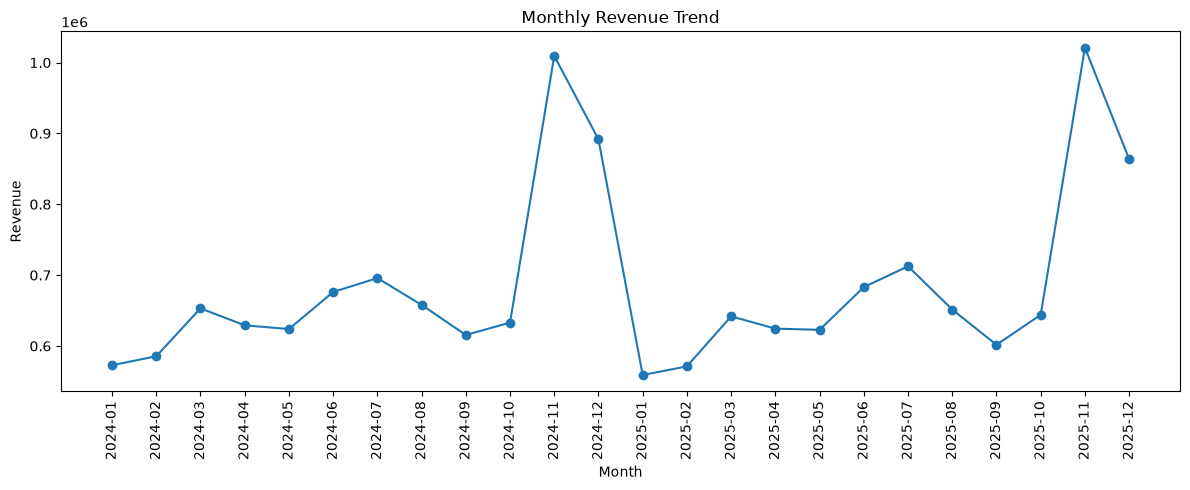

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(monthly["Year_Month"], monthly["Revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 10. Profit trend chart

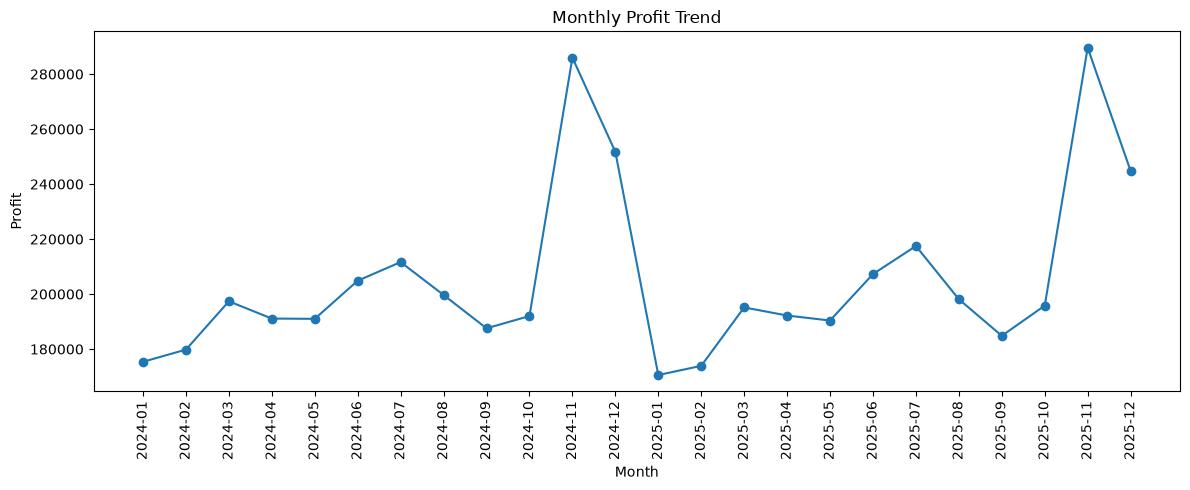

In [50]:
plt.figure(figsize=(12, 5))
plt.plot(monthly["Year_Month"], monthly["Profit"], marker="o")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 11. Year-over-year summary

In [51]:
yearly = (
    completed_sales
    .groupby("Year", as_index=False)
    .agg(
        Revenue=("Net_Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique"),
        Customers=("Customer_ID", "nunique")
    )
)

yearly["Profit_Margin"] = yearly["Profit"] / yearly["Revenue"]
yearly["Revenue_Growth_%"] = yearly["Revenue"].pct_change() * 100
yearly["Profit_Growth_%"] = yearly["Profit"].pct_change() * 100

yearly

,Year,Revenue,Profit,Orders,Customers,Profit_Margin,Revenue_Growth_%,Profit_Growth_%
0,2024,"8,244,074.49","2,468,214.74",53781,18343,0.30,NaN,NaN
1,2025,"8,196,544.04","2,460,200.27",53448,18281,0.30,-0.58,-0.32


# Part D — Category and Product Performance

## 12. Category performance

In [52]:
category_performance = (
    completed_sales
    .groupby("Category", as_index=False)
    .agg(
        Revenue=("Net_Sales", "sum"),
        Profit=("Profit", "sum"),
        Units=("Quantity", "sum"),
        Orders=("Order_ID", "nunique")
    )
)

category_performance["Profit_Margin"] = (
    category_performance["Profit"] / category_performance["Revenue"]
)

category_performance = category_performance.sort_values(
    "Revenue",
    ascending=False
)

category_performance

,Category,Revenue,Profit,Units,Orders,Profit_Margin
1,Electronics,"5,502,644.24","1,181,180.49",62008,36673,0.21
2,Fashion,"2,834,503.90","1,213,365.34",56997,34143,0.43
6,Sports & Outdoors,"2,521,323.09","789,315.83",47458,29096,0.31
3,Home & Kitchen,"2,450,720.30","696,968.60",51530,31353,0.28
4,Office,"1,615,222.12","418,272.34",40429,25130,0.26
0,Beauty,"816,419.81","385,897.02",29730,18935,0.47
5,Pet Supplies,"699,785.07","243,415.39",27980,17890,0.35


## 13. Revenue by category

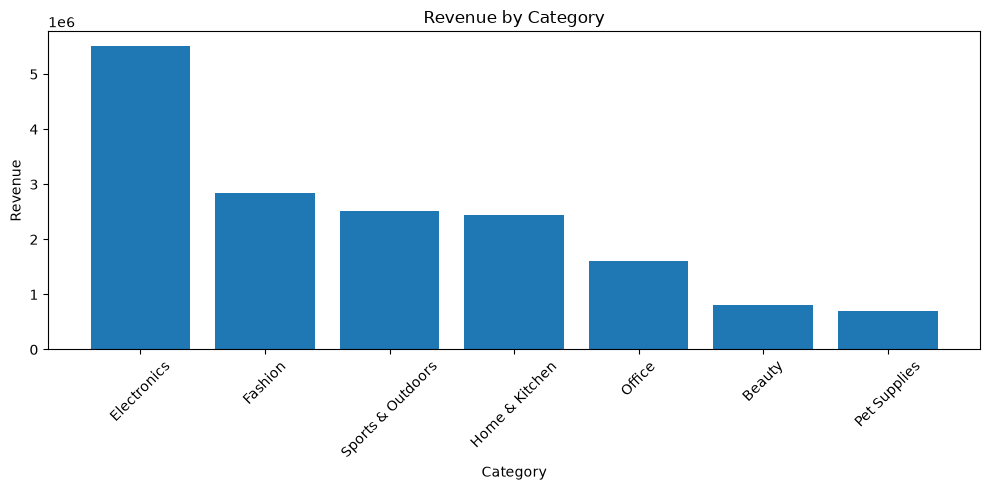

In [53]:
plt.figure(figsize=(10, 5))
plt.bar(
    category_performance["Category"],
    category_performance["Revenue"]
)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Profit margin by category

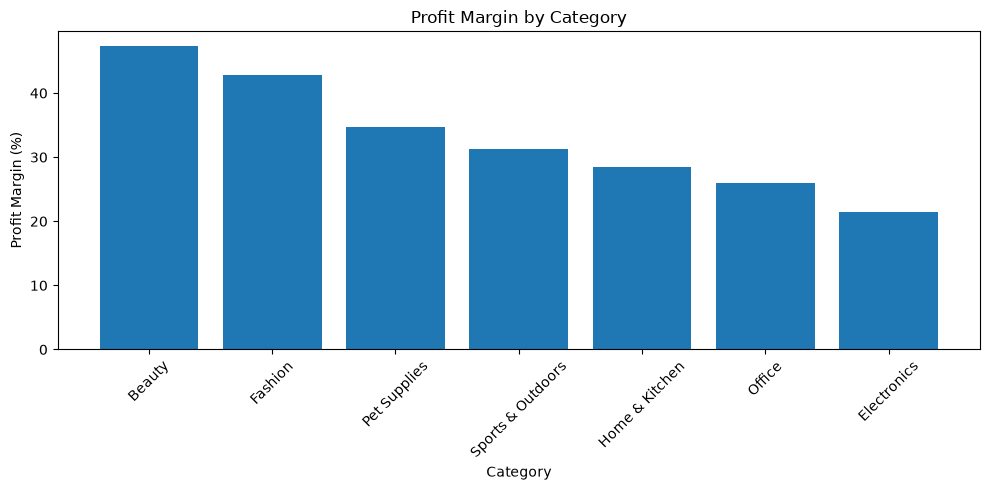

In [54]:
margin_by_category = category_performance.sort_values(
    "Profit_Margin",
    ascending=False
)

plt.figure(figsize=(10, 5))
plt.bar(
    margin_by_category["Category"],
    margin_by_category["Profit_Margin"] * 100
)
plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 15. Top 15 products by revenue

In [55]:
product_performance = (
    completed_sales
    .groupby(
        ["Product_ID", "Product_Name", "Category"],
        as_index=False
    )
    .agg(
        Revenue=("Net_Sales", "sum"),
        Profit=("Profit", "sum"),
        Units=("Quantity", "sum"),
        Orders=("Order_ID", "nunique")
    )
)

product_performance["Profit_Margin"] = (
    product_performance["Profit"]
    / product_performance["Revenue"]
)

top_products = product_performance.nlargest(
    15,
    "Revenue"
)

display(top_products)

,Product_ID,Product_Name,Category,Revenue,Profit,Units,Orders,Profit_Margin
1040,P01041,Mavix Max Smart Watches,Electronics,"266,772.17","53,652.89",3032,2123,0.20
130,P00131,Mavix Comfort Mice,Electronics,"236,348.00","63,078.32",904,601,0.27
317,P00318,Novexa Classic Fitness,Sports & Outdoors,"164,767.63","42,735.31",3208,2161,0.26
282,P00283,Mirello Classic Cookware,Home & Kitchen,"158,183.05","47,309.96",1073,735,0.30
496,P00497,Nexora Plus Accessories,Fashion,"143,520.96","58,846.23",2611,1806,0.41
607,P00608,Kentra Plus Mice,Electronics,"142,819.26","38,473.80",877,618,0.27
70,P00071,Brivon Comfort Cookware,Home & Kitchen,"130,615.78","38,430.17",2665,1859,0.29
750,P00751,Tekaro Comfort Cookware,Home & Kitchen,"123,256.15","40,850.51",3013,2022,0.33
623,P00624,Lumex Comfort Accessories,Fashion,"121,925.39","40,860.89",1870,1299,0.34
714,P00715,Calibre Plus Cycling,Sports & Outdoors,"114,407.79","36,612.34",1385,964,0.32


## 16. Top products chart

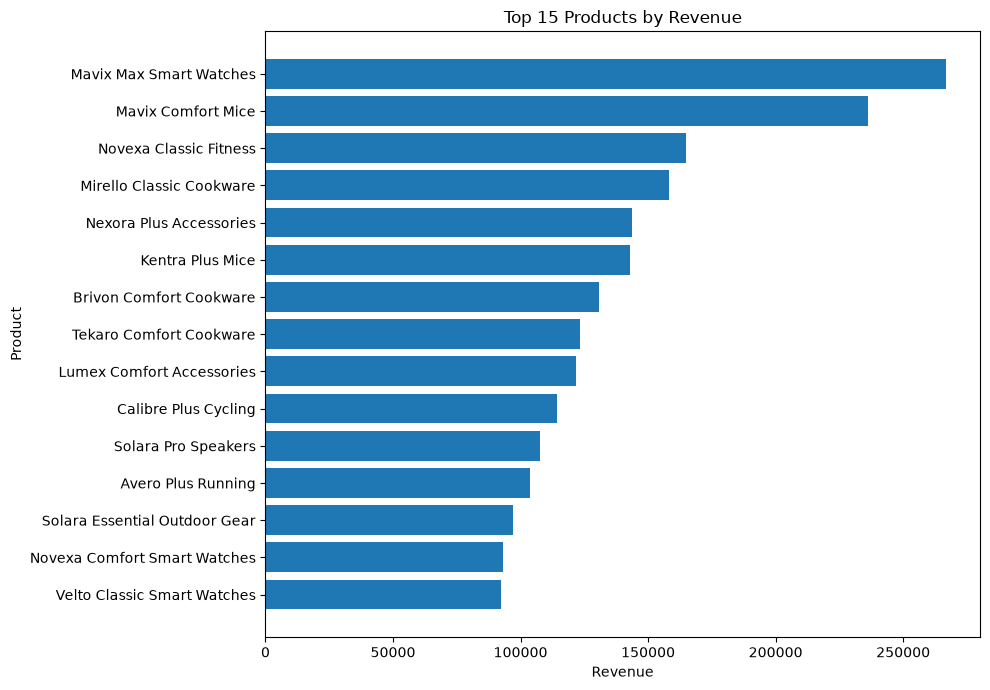

In [56]:
plot_df = top_products.sort_values("Revenue")

plt.figure(figsize=(10, 7))
plt.barh(
    plot_df["Product_Name"],
    plot_df["Revenue"]
)
plt.title("Top 15 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 17. High-revenue but low-margin products

This is a useful business question because high sales do not always mean good profitability.

In [57]:
revenue_threshold = product_performance["Revenue"].quantile(0.75)
margin_threshold = product_performance["Profit_Margin"].median()

high_revenue_low_margin = (
    product_performance[
        (product_performance["Revenue"] >= revenue_threshold)
        & (product_performance["Profit_Margin"] < margin_threshold)
    ]
    .sort_values("Revenue", ascending=False)
)

display(high_revenue_low_margin.head(20))

,Product_ID,Product_Name,Category,Revenue,Profit,Units,Orders,Profit_Margin
1040,P01041,Mavix Max Smart Watches,Electronics,"266,772.17","53,652.89",3032,2123,0.20
130,P00131,Mavix Comfort Mice,Electronics,"236,348.00","63,078.32",904,601,0.27
317,P00318,Novexa Classic Fitness,Sports & Outdoors,"164,767.63","42,735.31",3208,2161,0.26
282,P00283,Mirello Classic Cookware,Home & Kitchen,"158,183.05","47,309.96",1073,735,0.30
607,P00608,Kentra Plus Mice,Electronics,"142,819.26","38,473.80",877,618,0.27
70,P00071,Brivon Comfort Cookware,Home & Kitchen,"130,615.78","38,430.17",2665,1859,0.29
902,P00903,Solara Pro Speakers,Electronics,"107,706.45","18,182.51",1618,1133,0.17
1024,P01025,Solara Essential Outdoor Gear,Sports & Outdoors,"97,136.76","30,126.87",1709,1170,0.31
423,P00424,Novexa Comfort Smart Watches,Electronics,"92,924.63","15,483.63",644,434,0.17
534,P00535,Velto Classic Smart Watches,Electronics,"92,340.41","22,496.89",404,282,0.24


# Part E — Customer Analysis

## 18. Customer value table

In [58]:
customer_value = (
    completed_sales
    .groupby("Customer_ID", as_index=False)
    .agg(
        Revenue=("Net_Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique"),
        Units=("Quantity", "sum"),
        Last_Order=("Order_Date", "max"),
        First_Order=("Order_Date", "min")
    )
)

customer_value["Average_Order_Value"] = (
    customer_value["Revenue"]
    / customer_value["Orders"]
)

customer_value.sort_values(
    "Revenue",
    ascending=False
).head(20)

,Customer_ID,Revenue,Profit,Orders,Units,Last_Order,First_Order,Average_Order_Value
913,C001055,"7,051.67","2,060.48",33,116,2025-12-29,2024-01-15,213.69
4285,C004956,"6,769.69","2,073.86",42,129,2025-12-09,2024-03-23,161.18
21356,C024640,"6,558.19","1,957.50",38,127,2025-12-17,2024-02-07,172.58
12083,C013903,"6,125.57","1,681.62",25,102,2025-11-24,2024-01-20,245.02
11710,C013483,"5,880.32","1,728.06",36,116,2025-12-12,2024-01-30,163.34
12822,C014758,"5,851.14","1,771.07",34,117,2025-12-30,2024-01-08,172.09
3650,C004205,"5,702.55","1,648.92",23,89,2025-12-11,2024-01-10,247.94
8735,C010078,"5,447.21","1,392.26",28,100,2025-11-26,2024-02-06,194.54
8030,C009263,"5,401.88","1,623.52",28,113,2025-12-04,2024-01-16,192.92
20340,C023467,"5,381.13","1,519.33",33,99,2025-12-16,2024-01-03,163.06


## 19. Repeat customer rate

In [59]:
customer_order_counts = (
    completed_sales
    .groupby("Customer_ID")["Order_ID"]
    .nunique()
)

repeat_customers = (customer_order_counts > 1).sum()
one_time_customers = (customer_order_counts == 1).sum()
active_customers = len(customer_order_counts)

repeat_customer_rate = (
    repeat_customers / active_customers
    if active_customers
    else np.nan
)

print(f"Active customers: {active_customers:,}")
print(f"Repeat customers: {repeat_customers:,}")
print(f"One-time customers: {one_time_customers:,}")
print(f"Repeat customer rate: {repeat_customer_rate:.2%}")

Active customers: 21,669
Repeat customers: 17,886
One-time customers: 3,783
Repeat customer rate: 82.54%


## 20. Revenue by customer segment

In [60]:
segment_performance = (
    completed_sales
    .groupby("Customer_Segment", as_index=False)
    .agg(
        Revenue=("Net_Sales", "sum"),
        Profit=("Profit", "sum"),
        Customers=("Customer_ID", "nunique"),
        Orders=("Order_ID", "nunique")
    )
)

segment_performance["Revenue_Per_Customer"] = (
    segment_performance["Revenue"]
    / segment_performance["Customers"]
)

segment_performance["Average_Order_Value"] = (
    segment_performance["Revenue"]
    / segment_performance["Orders"]
)

segment_performance

,Customer_Segment,Revenue,Profit,Customers,Orders,Revenue_Per_Customer,Average_Order_Value
0,Consumer,"10,311,799.33","3,091,247.14",15355,69430,671.56,148.52
1,Professional,"2,935,375.57","880,600.36",2750,17955,"1,067.41",163.49
2,Small Business,"3,193,443.63","956,567.51",3564,19844,896.03,160.93


## 21. New vs returning customers by month

In [61]:
customer_first_order = (
    completed_sales
    .groupby("Customer_ID")["Order_Date"]
    .min()
)

customer_first_order.name = "First_Order_Date"

completed_sales = completed_sales.merge(
    customer_first_order,
    on="Customer_ID",
    how="left"
)

completed_sales["Customer_Type"] = np.where(
    completed_sales["Order_Date"]
    == completed_sales["First_Order_Date"],
    "New",
    "Returning"
)

new_returning = (
    completed_sales
    .groupby(
        ["Year_Month", "Customer_Type"],
        as_index=False
    )
    .agg(
        Customers=("Customer_ID", "nunique"),
        Revenue=("Net_Sales", "sum")
    )
)

new_returning.head()

,Year_Month,Customer_Type,Customers,Revenue
0,2024-01,New,3255,"502,672.88"
1,2024-01,Returning,383,"70,116.58"
2,2024-02,New,2706,"410,199.23"
3,2024-02,Returning,989,"175,291.80"
4,2024-03,New,2368,"364,071.09"


# Part F — Channel Performance

## 22. Revenue and profit by acquisition channel

In [62]:
channel_performance = (
    completed_sales
    .groupby("Channel", as_index=False)
    .agg(
        Revenue=("Net_Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique"),
        Customers=("Customer_ID", "nunique")
    )
)

channel_performance["Profit_Margin"] = (
    channel_performance["Profit"]
    / channel_performance["Revenue"]
)

channel_performance["Average_Order_Value"] = (
    channel_performance["Revenue"]
    / channel_performance["Orders"]
)

channel_performance.sort_values(
    "Revenue",
    ascending=False
)

,Channel,Revenue,Profit,Orders,Customers,Profit_Margin,Average_Order_Value
3,Organic Search,"4,061,809.71","1,282,357.11",25875,13518,0.32,156.98
4,Paid Search,"3,277,665.05","943,524.79",21590,12253,0.29,151.81
6,Social Media,"2,415,578.15","697,367.31",16132,10310,0.29,149.74
1,Email,"2,044,138.30","557,805.82",13772,9260,0.27,148.43
0,Direct,"2,005,614.80","633,416.30",12853,8835,0.32,156.04
2,Marketplace,"1,471,789.65","447,757.70",9568,7227,0.30,153.82
5,Referral,"1,164,022.87","366,185.98",7439,5944,0.31,156.48


## 23. Channel revenue chart

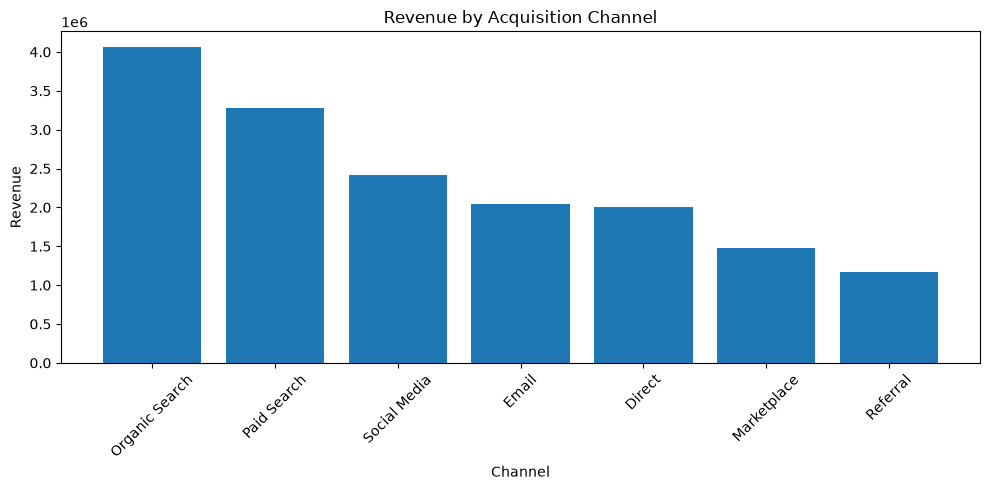

In [63]:
channel_plot = channel_performance.sort_values(
    "Revenue",
    ascending=False
)

plt.figure(figsize=(10, 5))
plt.bar(
    channel_plot["Channel"],
    channel_plot["Revenue"]
)
plt.title("Revenue by Acquisition Channel")
plt.xlabel("Channel")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Part G — Discount Analysis

## 24. Create discount bands

In [64]:
discount_analysis = completed_sales.copy()

discount_analysis["Discount_Band"] = pd.cut(
    discount_analysis["Discount_Pct"],
    bins=[-0.001, 0, 0.05, 0.10, 0.15, 0.20, 1],
    labels=[
        "0%",
        "1-5%",
        "6-10%",
        "11-15%",
        "16-20%",
        "20%+"
    ]
)

discount_summary = (
    discount_analysis
    .groupby("Discount_Band", observed=True, as_index=False)
    .agg(
        Revenue=("Net_Sales", "sum"),
        Profit=("Profit", "sum"),
        Units=("Quantity", "sum"),
        Orders=("Order_ID", "nunique")
    )
)

discount_summary["Profit_Margin"] = (
    discount_summary["Profit"]
    / discount_summary["Revenue"]
)

discount_summary

,Discount_Band,Revenue,Profit,Units,Orders,Profit_Margin
0,0%,"7,226,898.96","2,471,370.84",130714,63403,0.34
1,1-5%,"3,209,496.49","989,410.08",60931,35978,0.31
2,6-10%,"3,474,843.26","932,545.27",69671,40121,0.27
3,11-15%,"1,888,107.79","426,217.01",40080,24300,0.23
4,16-20%,"559,895.30","99,305.98",12708,8223,0.18
5,20%+,"81,376.73","9,565.83",2028,1353,0.12


## 25. Discount vs profit margin

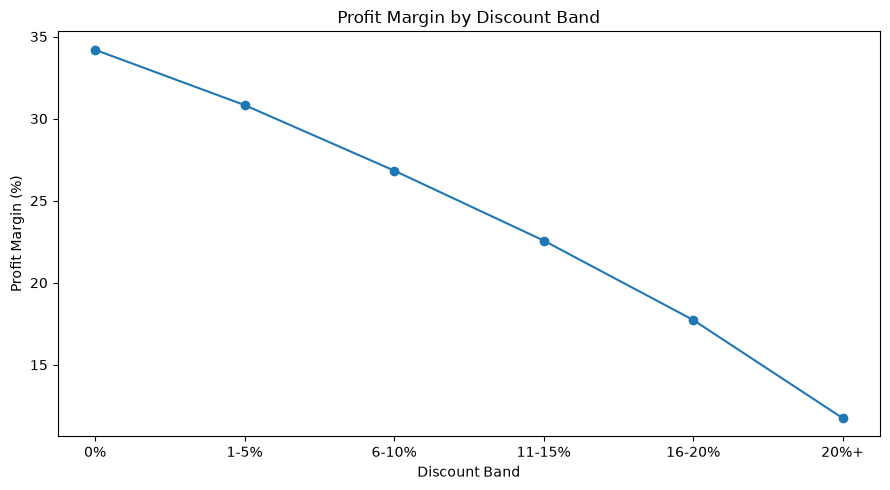

In [65]:
plt.figure(figsize=(9, 5))
plt.plot(
    discount_summary["Discount_Band"].astype(str),
    discount_summary["Profit_Margin"] * 100,
    marker="o"
)
plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

# Part H — Returns Analysis

## 26. Build return-enriched table

In [66]:
returns_enriched = (
    returns
    .merge(
        order_items[
            [
                "Order_Item_ID",
                "Order_ID",
                "Product_ID",
                "Quantity",
                "Net_Sales",
                "Profit"
            ]
        ],
        on=["Order_Item_ID", "Order_ID", "Product_ID"],
        how="left"
    )
    .merge(
        products[
            [
                "Product_ID",
                "Product_Name",
                "Category",
                "Subcategory"
            ]
        ],
        on="Product_ID",
        how="left"
    )
)

display(returns_enriched.head())

,Return_ID,Order_Item_ID,Order_ID,Product_ID,Return_Date,Return_Reason,Refund_Amount,Return_Status,Quantity,Net_Sales,Profit,Product_Name,Category,Subcategory
0,R000002,OI00000079,O0000034,P00467,2024-01-09,Damaged,11.37,Refunded,1,22.74,10.67,Tekaro Comfort Grooming,Beauty,Grooming
1,R000003,OI00000086,O0000036,P00187,2024-01-09,Wrong Size,108.70,Refunded,2,135.88,72.44,Novexa Flex T-Shirts,Fashion,T-Shirts
2,R000004,OI00000087,O0000037,P01183,2024-01-04,Compatibility Issue,363.39,Refunded,3,363.39,83.76,Novexa Max Keyboards,Electronics,Keyboards
3,R000005,OI00000091,O0000039,P00958,2024-01-19,Changed Mind,292.00,Refunded,2,292.00,159.20,Calibre Plus T-Shirts,Fashion,T-Shirts
4,R000006,OI00000095,O0000040,P00635,2024-01-15,Compatibility Issue,62.78,Refunded,1,62.78,12.07,Lumex Lite Power Banks,Electronics,Power Banks


## 27. Overall return KPIs

In [67]:
returned_items = returns["Order_Item_ID"].nunique()
sold_items = order_items["Order_Item_ID"].nunique()

return_rate = (
    returned_items / sold_items
    if sold_items
    else np.nan
)

total_refunds = returns["Refund_Amount"].sum()

print(f"Returned order items: {returned_items:,}")
print(f"Sold order items: {sold_items:,}")
print(f"Return rate: {return_rate:.2%}")
print(f"Total refunds: ${total_refunds:,.2f}")

Returned order items: 16,054
Sold order items: 227,167
Return rate: 7.07%
Total refunds: $1,263,573.77


## 28. Return reasons

In [68]:
return_reasons = (
    returns
    .groupby("Return_Reason", as_index=False)
    .agg(
        Returns=("Return_ID", "count"),
        Refund_Amount=("Refund_Amount", "sum")
    )
    .sort_values("Returns", ascending=False)
)

return_reasons

,Return_Reason,Returns,Refund_Amount
4,Not As Expected,4023,"309,443.48"
2,Damaged,3937,"316,034.96"
0,Changed Mind,2792,"178,764.26"
6,Wrong Size,2062,"145,698.86"
3,Defective,1209,"134,606.57"
5,Wrong Item,1065,"61,715.43"
1,Compatibility Issue,966,"117,310.21"


## 29. Return rate by category

In [69]:
sold_by_category = (
    completed_sales
    .groupby("Category")["Order_Item_ID"]
    .nunique()
)

returned_by_category = (
    returns_enriched
    .groupby("Category")["Order_Item_ID"]
    .nunique()
)

return_category = pd.DataFrame({
    "Sold_Items": sold_by_category,
    "Returned_Items": returned_by_category
}).fillna(0)

return_category["Return_Rate"] = (
    return_category["Returned_Items"]
    / return_category["Sold_Items"]
)

return_category = (
    return_category
    .reset_index()
    .sort_values("Return_Rate", ascending=False)
)

return_category

,Category,Sold_Items,Returned_Items,Return_Rate
2,Fashion,39254,5119,0.13
1,Electronics,42856,3685,0.09
6,Sports & Outdoors,32729,2375,0.07
3,Home & Kitchen,35539,2054,0.06
0,Beauty,20432,982,0.05
4,Office,27762,1154,0.04
5,Pet Supplies,19217,685,0.04


## 30. Return-rate chart

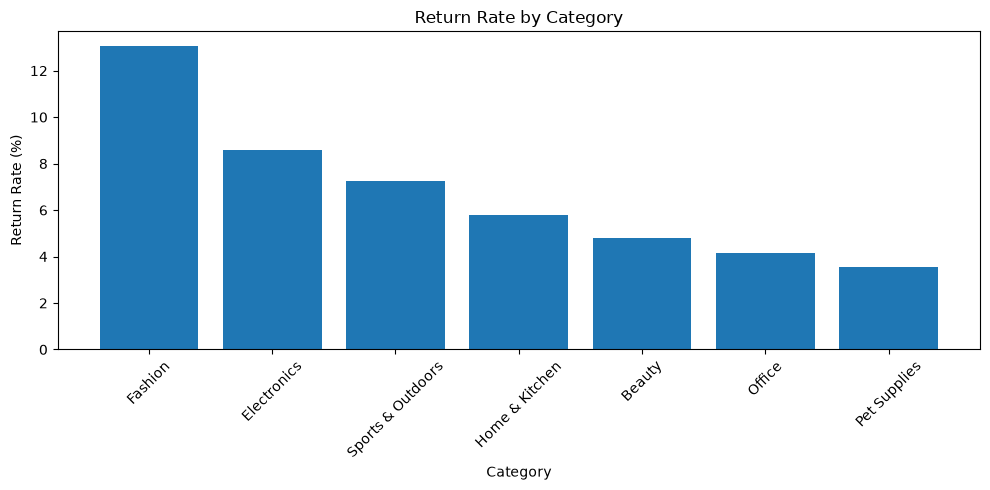

In [70]:
plt.figure(figsize=(10, 5))
plt.bar(
    return_category["Category"],
    return_category["Return_Rate"] * 100
)
plt.title("Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Part I — Geographic Analysis

## 31. Sales by city

In [71]:
city_performance = (
    completed_sales
    .groupby(["City", "State"], as_index=False)
    .agg(
        Revenue=("Net_Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique"),
        Customers=("Customer_ID", "nunique")
    )
)

city_performance["Profit_Margin"] = (
    city_performance["Profit"]
    / city_performance["Revenue"]
)

city_performance.sort_values(
    "Revenue",
    ascending=False
).head(20)

,City,State,Revenue,Profit,Orders,Customers,Profit_Margin
14,Other,Other,"4,969,445.81","1,486,309.49",32348,6555,0.30
12,New York,NY,"1,557,839.09","466,615.43",10072,2020,0.30
9,Los Angeles,CA,"1,216,671.63","366,630.15",8054,1705,0.30
4,Chicago,IL,"875,257.14","263,556.57",5742,1177,0.30
8,Houston,TX,"863,854.97","257,914.27",5541,1124,0.30
16,Phoenix,AZ,"524,083.93","155,771.20",3400,700,0.30
6,Dallas,TX,"523,842.56","158,686.38",3446,671,0.30
15,Philadelphia,PA,"478,111.78","143,463.46",3188,679,0.30
7,Denver,CO,"473,082.95","143,510.74",3155,619,0.30
10,Miami,FL,"464,256.60","138,952.71",3034,608,0.30


## 32. Top 10 cities chart

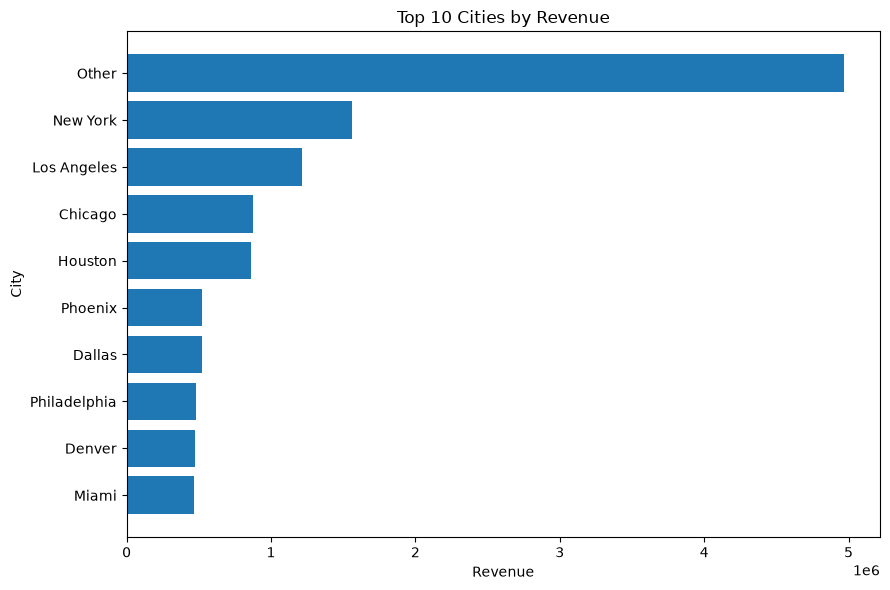

In [72]:
top_cities = (
    city_performance
    .sort_values("Revenue", ascending=False)
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_cities["City"],
    top_cities["Revenue"]
)
plt.title("Top 10 Cities by Revenue")
plt.xlabel("Revenue")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# Part J — Marketing Analysis

## 33. Marketing efficiency by channel

In [73]:
marketing_channel = (
    marketing
    .groupby("Channel", as_index=False)
    .agg(
        Spend=("Spend", "sum"),
        Impressions=("Impressions", "sum"),
        Clicks=("Clicks", "sum"),
        Attributed_Orders=("Attributed_Orders", "sum")
    )
)

marketing_channel["CTR"] = (
    marketing_channel["Clicks"]
    / marketing_channel["Impressions"]
)

marketing_channel["Conversion_Rate"] = (
    marketing_channel["Attributed_Orders"]
    / marketing_channel["Clicks"]
)

marketing_channel["Cost_Per_Click"] = (
    marketing_channel["Spend"]
    / marketing_channel["Clicks"]
)

marketing_channel["Cost_Per_Attributed_Order"] = (
    marketing_channel["Spend"]
    / marketing_channel["Attributed_Orders"]
)

marketing_channel.sort_values(
    "Cost_Per_Attributed_Order"
)

,Channel,Spend,Impressions,Clicks,Attributed_Orders,CTR,Conversion_Rate,Cost_Per_Click,Cost_Per_Attributed_Order
0,Email,"314,124.59",64339411,"3,324,043.00",189623,0.05,0.06,0.09,1.66
3,Referral,"250,581.07",13883863,"391,264.00",19096,0.03,0.05,0.64,13.12
1,Marketplace,"597,790.74",25211367,"777,487.00",34413,0.03,0.04,0.77,17.37
2,Paid Search,"1,291,496.80",40359238,"1,469,610.00",61554,0.04,0.04,0.88,20.98
4,Social Media,"884,646.36",81488237,"1,452,240.00",34932,0.02,0.02,0.61,25.32


## 34. Compare marketing spend with sales by channel

This is not a perfect attribution model, but it is useful for directional portfolio analysis.

In [74]:
sales_channel_revenue = (
    completed_sales
    .groupby("Channel", as_index=False)
    .agg(
        Sales_Revenue=("Net_Sales", "sum"),
        Sales_Profit=("Profit", "sum")
    )
)

marketing_sales = marketing_channel.merge(
    sales_channel_revenue,
    on="Channel",
    how="left"
)

marketing_sales["Revenue_to_Spend"] = (
    marketing_sales["Sales_Revenue"]
    / marketing_sales["Spend"]
)

marketing_sales.sort_values(
    "Revenue_to_Spend",
    ascending=False
)

,Channel,Spend,Impressions,Clicks,Attributed_Orders,CTR,Conversion_Rate,Cost_Per_Click,Cost_Per_Attributed_Order,Sales_Revenue,Sales_Profit,Revenue_to_Spend
0,Email,"314,124.59",64339411,"3,324,043.00",189623,0.05,0.06,0.09,1.66,"2,044,138.30","557,805.82",6.51
3,Referral,"250,581.07",13883863,"391,264.00",19096,0.03,0.05,0.64,13.12,"1,164,022.87","366,185.98",4.65
4,Social Media,"884,646.36",81488237,"1,452,240.00",34932,0.02,0.02,0.61,25.32,"2,415,578.15","697,367.31",2.73
2,Paid Search,"1,291,496.80",40359238,"1,469,610.00",61554,0.04,0.04,0.88,20.98,"3,277,665.05","943,524.79",2.54
1,Marketplace,"597,790.74",25211367,"777,487.00",34413,0.03,0.04,0.77,17.37,"1,471,789.65","447,757.70",2.46


# Part K — Operational Analysis

## 35. Shipping performance

In [75]:
shipping_analysis = orders[
    orders["Order_Status"] == "Completed"
].copy()

shipping_analysis["Shipping_Days"] = (
    shipping_analysis["Ship_Date"]
    - shipping_analysis["Order_Date"]
).dt.days

shipping_summary = (
    shipping_analysis
    .groupby("Shipping_Method", as_index=False)
    .agg(
        Orders=("Order_ID", "nunique"),
        Average_Shipping_Days=("Shipping_Days", "mean"),
        Median_Shipping_Days=("Shipping_Days", "median")
    )
)

shipping_summary

,Shipping_Method,Orders,Average_Shipping_Days,Median_Shipping_Days
0,Express,21552,2.00,2.00
1,Same Day,4159,0.50,0.00
2,Standard,81306,4.00,4.00
3,Unknown,238,3.34,3.00


## 36. Sales by day of week

In [76]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_performance = (
    completed_sales
    .groupby("Day_Name", as_index=False)
    .agg(
        Revenue=("Net_Sales", "sum"),
        Orders=("Order_ID", "nunique")
    )
)

day_performance["Day_Name"] = pd.Categorical(
    day_performance["Day_Name"],
    categories=day_order,
    ordered=True
)

day_performance = day_performance.sort_values("Day_Name")
day_performance

,Day_Name,Revenue,Orders
1,Monday,"2,293,038.11",14950
5,Tuesday,"2,293,699.45",14959
6,Wednesday,"2,290,350.06",14990
4,Thursday,"2,270,876.12",14781
0,Friday,"2,290,948.39",14876
2,Saturday,"2,552,581.71",16643
3,Sunday,"2,449,124.69",16030


# Part L — Management Insight Tables

## 37. Best and weakest categories

In [77]:
best_revenue_category = (
    category_performance
    .sort_values("Revenue", ascending=False)
    .iloc[0]
)

best_margin_category = (
    category_performance
    .sort_values("Profit_Margin", ascending=False)
    .iloc[0]
)

lowest_margin_category = (
    category_performance
    .sort_values("Profit_Margin")
    .iloc[0]
)

print(
    "Highest revenue category:",
    best_revenue_category["Category"],
    f"(${best_revenue_category['Revenue']:,.2f})"
)

print(
    "Highest margin category:",
    best_margin_category["Category"],
    f"({best_margin_category['Profit_Margin']:.2%})"
)

print(
    "Lowest margin category:",
    lowest_margin_category["Category"],
    f"({lowest_margin_category['Profit_Margin']:.2%})"
)

Highest revenue category: Electronics ($5,502,644.24)
Highest margin category: Beauty (47.27%)
Lowest margin category: Electronics (21.47%)


## 38. Top customers

In [78]:
top_customers = (
    customer_value
    .sort_values("Revenue", ascending=False)
    .head(20)
)

top_customers

,Customer_ID,Revenue,Profit,Orders,Units,Last_Order,First_Order,Average_Order_Value
913,C001055,"7,051.67","2,060.48",33,116,2025-12-29,2024-01-15,213.69
4285,C004956,"6,769.69","2,073.86",42,129,2025-12-09,2024-03-23,161.18
21356,C024640,"6,558.19","1,957.50",38,127,2025-12-17,2024-02-07,172.58
12083,C013903,"6,125.57","1,681.62",25,102,2025-11-24,2024-01-20,245.02
11710,C013483,"5,880.32","1,728.06",36,116,2025-12-12,2024-01-30,163.34
12822,C014758,"5,851.14","1,771.07",34,117,2025-12-30,2024-01-08,172.09
3650,C004205,"5,702.55","1,648.92",23,89,2025-12-11,2024-01-10,247.94
8735,C010078,"5,447.21","1,392.26",28,100,2025-11-26,2024-02-06,194.54
8030,C009263,"5,401.88","1,623.52",28,113,2025-12-04,2024-01-16,192.92
20340,C023467,"5,381.13","1,519.33",33,99,2025-12-16,2024-01-03,163.06


## 39. Top return-risk products

We calculate return rate at product level and only include products with a reasonable sales volume.

In [79]:
sold_by_product = (
    completed_sales
    .groupby(
        ["Product_ID", "Product_Name", "Category"]
    )["Order_Item_ID"]
    .nunique()
)

returned_by_product = (
    returns_enriched
    .groupby(
        ["Product_ID", "Product_Name", "Category"]
    )["Order_Item_ID"]
    .nunique()
)

product_returns = pd.concat(
    [
        sold_by_product.rename("Sold_Items"),
        returned_by_product.rename("Returned_Items")
    ],
    axis=1
).fillna(0)

product_returns["Return_Rate"] = (
    product_returns["Returned_Items"]
    / product_returns["Sold_Items"]
)

product_returns = (
    product_returns
    .reset_index()
)

high_volume_return_risk = (
    product_returns[
        product_returns["Sold_Items"] >= 50
    ]
    .sort_values("Return_Rate", ascending=False)
    .head(20)
)

high_volume_return_risk

,Product_ID,Product_Name,Category,Sold_Items,Returned_Items,Return_Rate
1111,P01112,Mavix Max Shoes,Fashion,50,11.00,0.22
978,P00979,Mirello Flex Bags,Fashion,84,18.00,0.21
686,P00687,Orbito Pro Accessories,Fashion,52,11.00,0.21
572,P00573,Nexora Flex Bags,Fashion,81,17.00,0.21
321,P00322,Lumex Max Accessories,Fashion,83,17.00,0.20
384,P00385,Orbito Pro Shoes,Fashion,54,11.00,0.20
733,P00734,Nexora Elite Jeans,Fashion,50,10.00,0.20
303,P00304,Avero Plus Jackets,Fashion,51,10.00,0.20
1107,P01108,Velto Lite T-Shirts,Fashion,99,19.00,0.19
650,P00651,Brivon Max Jeans,Fashion,73,14.00,0.19


# Part M — Export Analysis Tables

## 40. Save important analysis outputs

These summary tables can later be used for:

- SQL cross-checking
- Power BI validation
- README documentation
- Fiverr portfolio screenshots

In [80]:
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

monthly.to_csv(
    REPORT_DIR / "monthly_performance.csv",
    index=False
)

category_performance.to_csv(
    REPORT_DIR / "category_performance.csv",
    index=False
)

product_performance.to_csv(
    REPORT_DIR / "product_performance.csv",
    index=False
)

customer_value.to_csv(
    REPORT_DIR / "customer_value.csv",
    index=False
)

channel_performance.to_csv(
    REPORT_DIR / "channel_performance.csv",
    index=False
)

return_category.to_csv(
    REPORT_DIR / "return_rate_by_category.csv",
    index=False
)

marketing_sales.to_csv(
    REPORT_DIR / "marketing_channel_performance.csv",
    index=False
)

print("Analysis tables exported to:", REPORT_DIR.resolve())

Analysis tables exported to: C:\Users\Didar\Desktop\Ecommerce_Analytics_Project\reports


# Final Step — Portfolio Insight Checklist

After running the notebook, record the actual values for these questions:

1. What is total revenue?
2. What is total profit?
3. What is overall profit margin?
4. What is average order value?
5. Which year grew faster?
6. Which category generates the most revenue?
7. Which category has the highest profit margin?
8. Which category has the highest return rate?
9. What percentage of customers are repeat buyers?
10. Which customer segment has the highest revenue per customer?
11. Which acquisition channel generates the most revenue?
12. How does deeper discounting affect profit margin?
13. Which cities generate the most revenue?
14. Which marketing channel has the lowest cost per attributed order?
15. Which high-volume products have unusually high return rates?

These answers will become the management insights on the final Power BI dashboard and project README.